## Analysing experimental data

The 10 year PS data set provides multiple IRFs and events recorded in the particular detector configurations, starting with `IC40` and ending with `IC86_VII`, although the detector configuration did not change after `IC86_II`.

As an example we consider TXS0506+056 during the 2014/2015 flare.

In [1]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from hierarchical_nu.source.parameter import Parameter
from hierarchical_nu.simulation import Simulation
from hierarchical_nu.fit import StanFit
from hierarchical_nu.priors import Priors
from hierarchical_nu.source.source import Sources, PointSource, DetectorFrame
from hierarchical_nu.utils.lifetime import LifeTime
from hierarchical_nu.events import Events
from hierarchical_nu.fit import StanFit
from hierarchical_nu.priors import (
    Priors,
    LogNormalPrior,
    NormalPrior,
    LuminosityPrior,
    IndexPrior,
    FluxPrior,
    DifferentialFluxPrior,
)
from hierarchical_nu.utils.roi import CircularROI
from hierarchical_nu.detector.icecube import IC86_II, IC86_I
from hierarchical_nu.detector.input import mceq
from icecube_tools.utils.data import Uptime
import numpy as np
import ligo.skymap.plot

First, we define the source and fit parameters, as already seen in `simulate_and_fit`. The value of e.g. `src_index` has no meaning in this context. Relevant for the fit is only the existance of the parameter itself. We can, however, use the parameter values to make decisions on which priors to choose by gauging how many events are to be expected by a certain choice of parameters.

In [2]:
# define high-level parameters
Parameter.clear_registry()
src_index = Parameter(2.2, "src_index", fixed=False, par_range=(1, 4))
diff_index = Parameter(2.52, "diff_index", fixed=False, par_range=(1, 4))
L = Parameter(
    1e47 * (u.erg / u.s), "luminosity", fixed=True, par_range=(0, 1e60) * (u.erg / u.s)
)
diffuse_norm = Parameter(
    2.26e-13 / u.GeV / u.m**2 / u.s,
    "diffuse_norm",
    fixed=True,
    par_range=(1e-14, 1e-11) * (1 / u.GeV / u.s / u.m**2),
)
z = 0.3365
Enorm = Parameter(1e5 * u.GeV, "Enorm", fixed=True)
Emin = Parameter(1e2 * u.GeV, "Emin", fixed=True)
Emax = Parameter(1e8 * u.GeV, "Emax", fixed=True)
Emin_src = Parameter(Emin.value, "Emin_src", fixed=True)
Emax_src = Parameter(Emax.value, "Emax_src", fixed=True)
Emin_diff = Parameter(Emin.value, "Emin_diff", fixed=True)
Emax_diff = Parameter(Emax.value, "Emax_diff", fixed=True)

In [3]:
Emin_det = Parameter(3e2 * u.GeV, "Emin_det", fixed=True)

In [4]:
# Single PS for testing and usual components
ra = np.deg2rad(77.35) * u.rad
dec = np.deg2rad(5.7) * u.rad
width = np.deg2rad(6) * u.rad
txs = SkyCoord(ra=ra, dec=dec, frame="icrs")
point_source = PointSource.make_powerlaw_source(
    "test",
    dec,
    ra,
    L,
    src_index,
    z,
    Emin_src,
    Emax_src,
    DetectorFrame,
)

my_sources = Sources()
my_sources.add(point_source)
my_sources.add_diffuse_component(
    diffuse_norm, Enorm.value, diff_index, Emin_diff, Emax_diff
)
my_sources.add_atmospheric_component(cache_dir=mceq)

We now need to decide on the time period of observation (start and end times in MJD). The detector lifetime is automatically calculated from the "good time intervals" provided in the data release. Event selection respects the start and end times with which an ROI is instanciated.

From the [paper](https://arxiv.org/pdf/2101.09836.pdf) accompanying the data release, Table IV, we can guesstimate (Tmin, Tmax) = (56917, 57113). This is not the result of a flare analysis, but rather to include all contributing events.

Together with the source location we create an ROI.

In [5]:
MJD_min = 56917
MJD_max = 57113

roi = CircularROI(txs, 5 * u.deg, MJD_min=MJD_min, MJD_max=MJD_max, apply_roi=True)

A `LifeTime` instance computes the detector lifetime in the chosen time range.

In [6]:
lt = LifeTime()
lifetime = lt.lifetime_from_mjd(MJD_min, MJD_max)
print(lifetime)

{<class 'hierarchical_nu.detector.icecube.IC86_II'>: <Quantity 0.49401826 yr>}


Returned is dictionary with event type as key and lifetime in years as value. We can re-use this return value to get a list of event types as input for the fit.

In [7]:
event_types = list(lifetime.keys())

In [8]:
events = Events.from_ev_file(*event_types)
print(events.N)

231


We take a small detour to setup a simulation. Through `sim._get_expected_Nnu` we are able to calculate the expected number of events.
Due to a mismatch between data and MC it is currently sensible to set a prior on the atmospheric flux that will account for the selected number of events, rather than the MCEq-simulated flux value.

Assuming all data is background, we rescale the atmospheric flux to produce the number of events in the data sample. Data taking is a Poisson counts experiment, meaning that $\sqrt{N}$ is the standard deviation of $N$.

In [9]:
sim = Simulation(my_sources, event_types, lifetime)

In [10]:
sim.precomputation()
print(sim._get_expected_Nnu(sim._get_sim_inputs()))
print(sim._expected_Nnu_per_comp)

203.61230814182926
[ 11.13704038   1.0626075  191.41266027]


For each physical parameter there is a seperate prior class implemented, e.g. for the luminosity a `LuminosityPrior`. We can pass different types of distributions, namely `NormalPrior`, `LogNormalPrior` and for the luminosity only `ParetoPrior` with appropriate $\mu, \sigma$ (or $x_{min}, \alpha$). The priors convert the passed units to the internally used ones. `IndexPrior` does not use units. Fluxes are integrated number fluxes, i.e. dimension is 1 / area / time.

In [11]:
priors = Priors()
priors.luminosity = LuminosityPrior(
    mu=L.value / sim.expected_Nnu_per_comp[0] * 10, sigma=2  # we expect ~10 events
)
priors.src_index = IndexPrior(mu=2.5, sigma=1)

In [12]:
# Copy flux
atmo_flux_int = my_sources.atmospheric.flux_model.total_flux_int
Nex = np.sum(sim.expected_Nnu_per_comp[2])
Nex_std = np.sqrt(Nex)
N = events.N
N_std = np.sqrt(N)
# Nex is mean of poisson and at zeroth order all background
# std is sqrt(Nex) -> add to Nex and convert to flux
# this flux is then 1sigma above mean
mu = atmo_flux_int / Nex * N
sigma = atmo_flux_int / Nex * np.sqrt(N)
# N +/- N_std -> N_std is sigma on scale of events
# atmo_flux_int +/- sigma should yield N +/- N_std events
priors.atmospheric_flux = FluxPrior(mu=mu, sigma=sigma)

In [13]:
lifetime

{hierarchical_nu.detector.icecube.IC86_II: <Quantity 0.49401826 yr>}

In [14]:
fit = StanFit(my_sources, event_types, events, lifetime, nshards=40)

In [15]:
fit.precomputation()

In [16]:
fit.generate_stan_code()
fit.compile_stan_code()

10:57:01 - cmdstanpy - INFO - compiling stan file /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/model_code.stan to exe file /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/model_code
10:57:29 - cmdstanpy - INFO - compiled model executable: /home/iwsatlas1/kuhlmann/icecube/hierarchical_nu/examples/.stan_files/model_code


Run the fit with some appropriate initial values. With 40 threads, this will take roughly 6 minutes (subject to change, hopefully for the better).

In [17]:
fit.run(
    show_progress=True,
    inits={
        "L": 1e48,
        "src_index": 2.2,
        "diff_index": 2.2,
        "F_atmo": 0.3,
        "diffuse_norm": 2.2e-13,
    },
)

10:57:51 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

10:58:39 - cmdstanpy - INFO - CmdStan done processing.


Confirm that there are no problems encountered by the HMC.

In [20]:
fit.diagnose()

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  lp[1,1], lp[193,1]
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizating your model with additional prior information or a more effective parameterization.

Processing complete.



Display the posterior distributions alongside the inputted prior distributions, where available.

Compare the results to those of a likelihood analysis by IceCube: ns=11.87, gamma=2.22

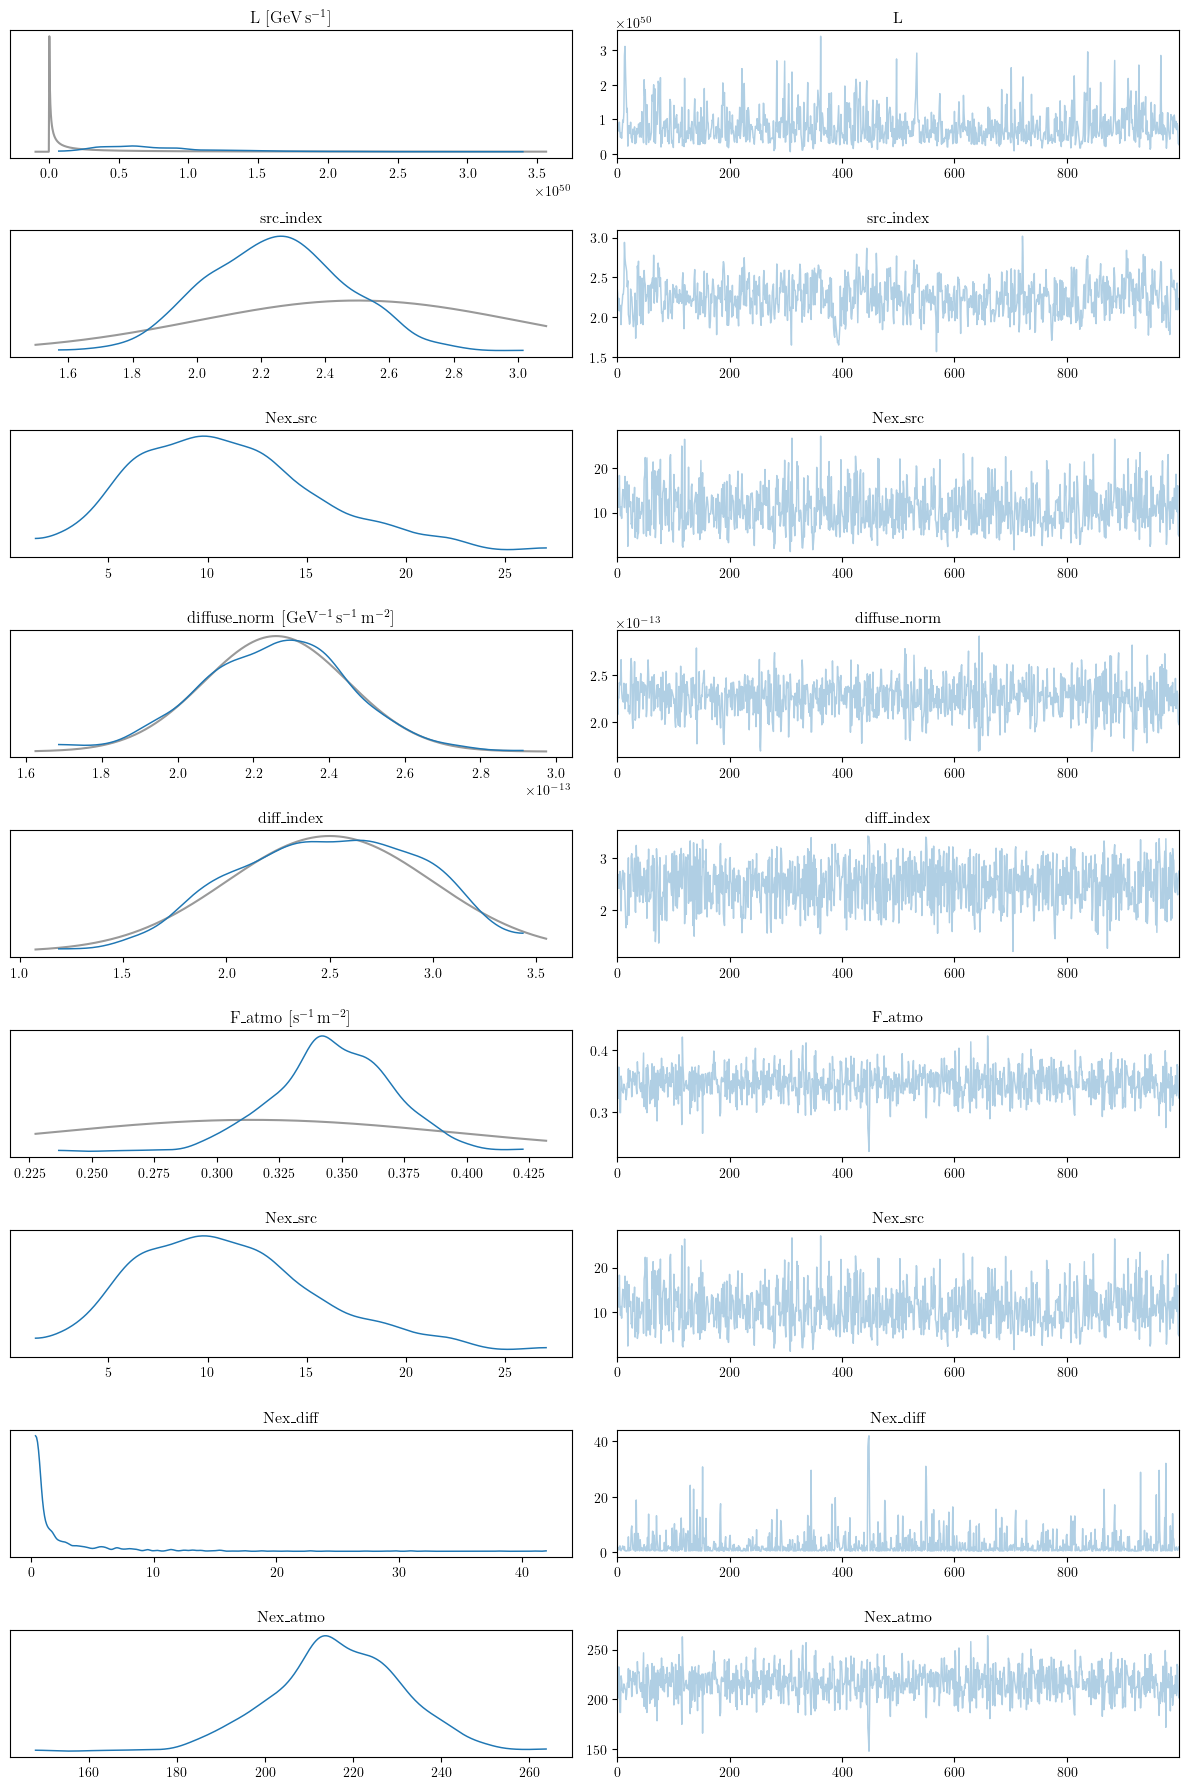

In [19]:
fig, ax = fit.plot_trace_and_priors(
    var_names=fit._def_var_names + ["Nex_src", "Nex_diff", "Nex_atmo"]
)
fig.tight_layout()

Marginalising over all posteriors, the association probability of each event with a source component can be extracted. Displayed in the following plots are a spatial and an energetic overview of all events. The blob size is arbitrary. The colorscale encodes the association probability, here to the proposed point source marked by a grey cross in the left plot.

On the right, the energy posteriors of each event is shown. The distributions are transformed to $\log_{10}(E / \text{GeV})$. At the top, reconstructed energies of all selected events are shown as short vertical lines. Above an association probability of 20% they are linked by a dashed line to the corresponding posterior distribution.

(0.0, 1.1984486510897014)

/home/iwsatlas1/kuhlmann/envs/hnu/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/iwsatlas1/kuhlmann/envs/hnu/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


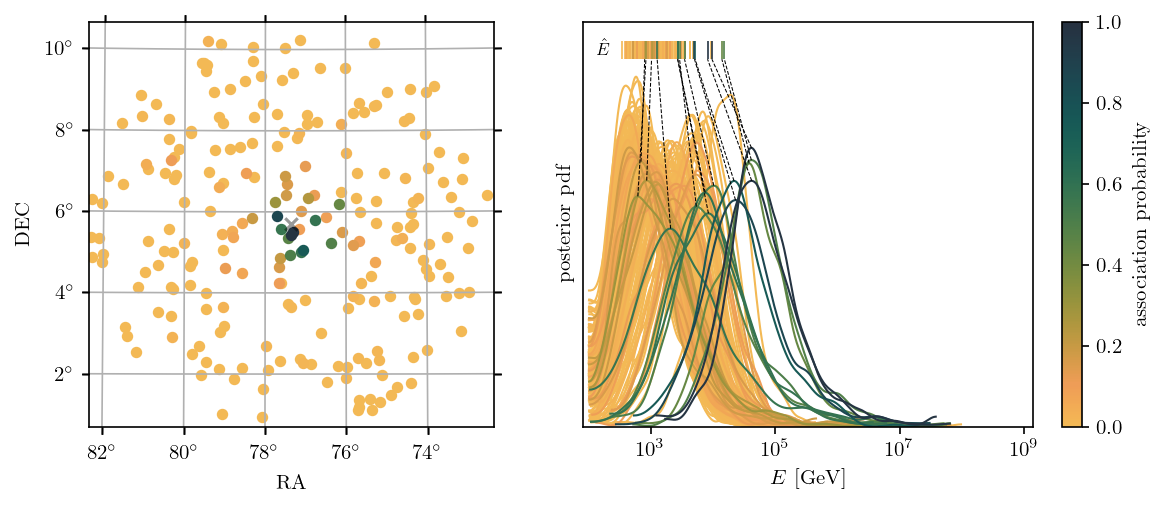

In [ ]:
fig, axs = fit.plot_energy_and_roi()

Lastly, show the correlations between the parameters.

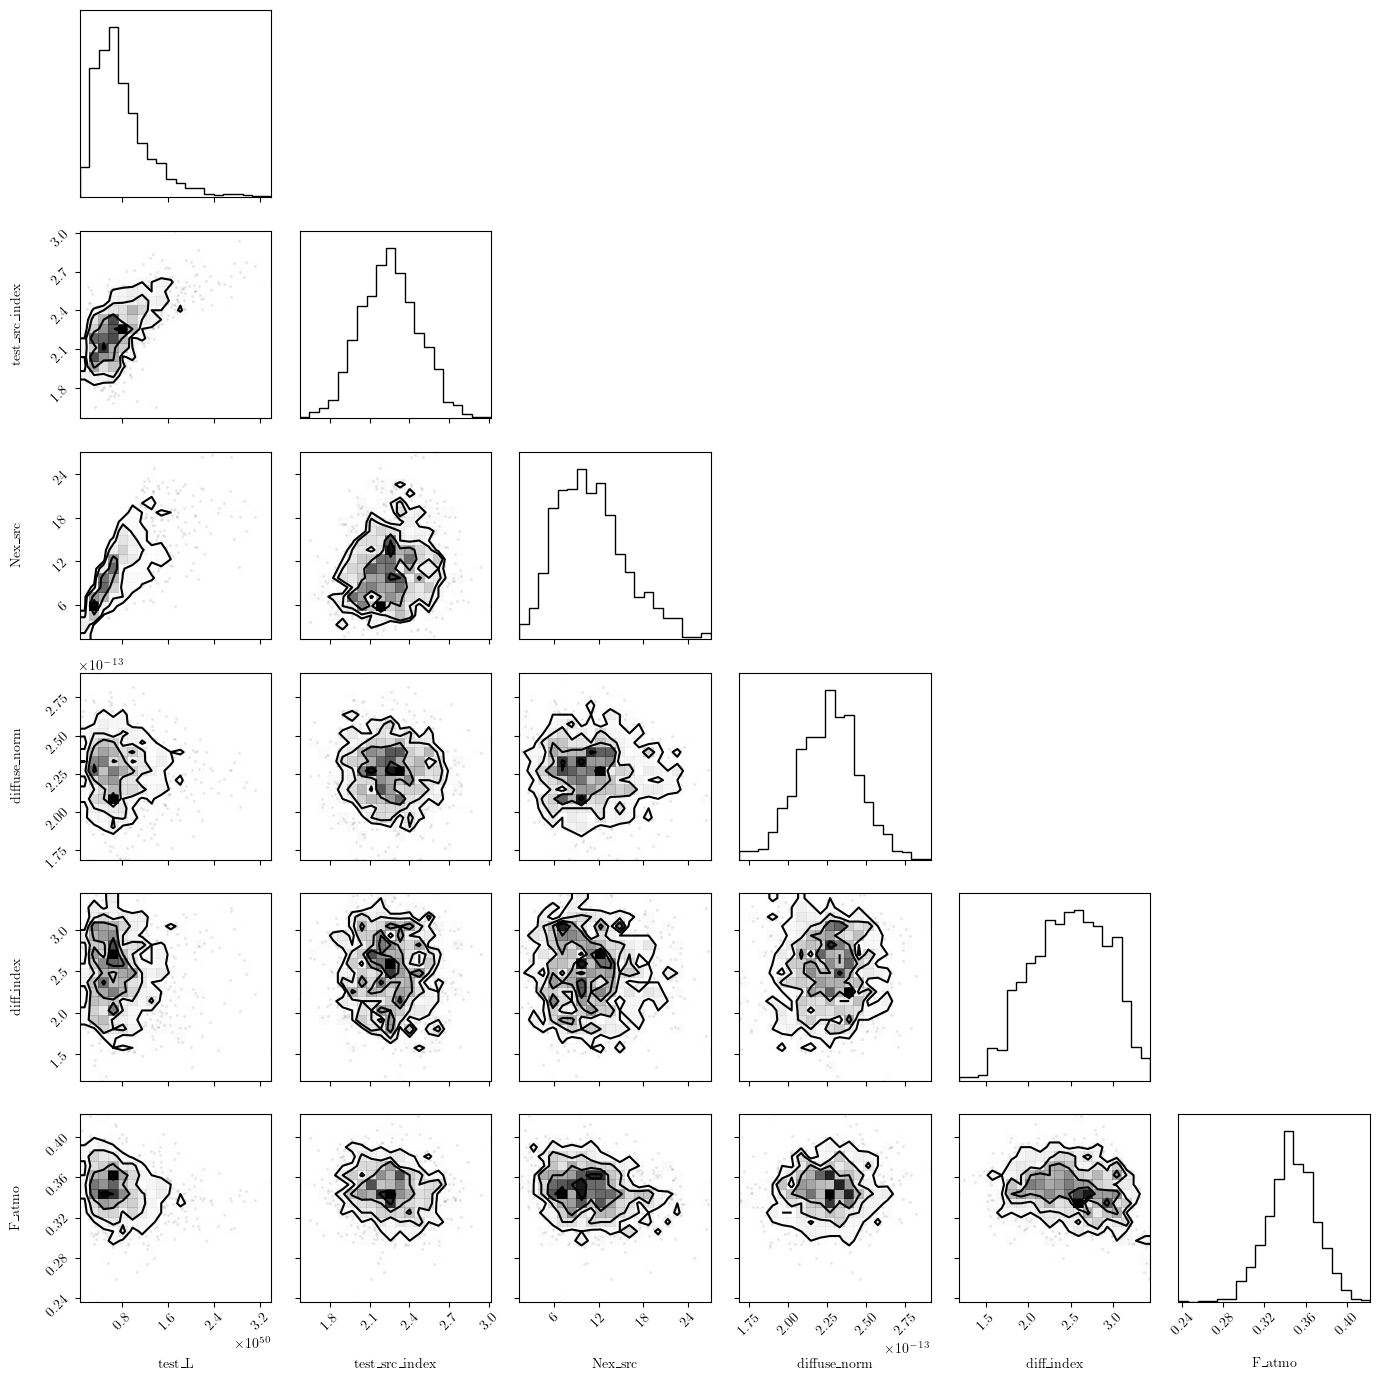

In [ ]:
fit.corner_plot()